# Prophet

In [4]:
from prophet import Prophet
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [8]:
df_hourly = pd.read_csv(r"C:\Users\dpine\red_electrica\red_electrica\data\df_hourly.csv")

In [9]:
df_prophet = df_hourly.reset_index().rename(columns={'date': 'ds', 'value': 'y'})

In [10]:
df_prophet['ds'] = pd.to_datetime(df_prophet['ds'].values).tz_localize(None)

In [11]:
train_prophet = df_prophet[df_prophet['ds'] < '2025-03-29'].copy()
valid_prophet = df_prophet[df_prophet['ds'] >= '2025-03-29'].copy()

In [12]:
valid_prophet['ds'] = pd.to_datetime(valid_prophet['ds'].values).tz_localize(None)

In [13]:
m = Prophet(
    daily_seasonality=True,
    weekly_seasonality=True,
    yearly_seasonality=False
)

In [14]:
m.fit(train_prophet)

21:52:37 - cmdstanpy - INFO - Chain [1] start processing
21:53:36 - cmdstanpy - INFO - Chain [1] done processing


In [15]:
future = m.make_future_dataframe(periods=len(valid_prophet), freq='H')

c:\Users\dpine\red_electrica\red_electrica\venv2\Lib\site-packages\prophet\forecaster.py:1854: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  dates = pd.date_range(


In [16]:
forecast = m.predict(future)

In [17]:
forecast = forecast[['ds', 'yhat']].set_index('ds')
results = forecast.join(valid_prophet.set_index('ds'), how='right')

In [18]:
rmse = np.sqrt(mean_squared_error(results['y'], results['yhat']))
mae = mean_absolute_error(results['y'], results['yhat'])

print(f'RMSE: {rmse:.2f}')
print(f'MAE: {mae:.2f}')

RMSE: 3728.47
MAE: 3061.51


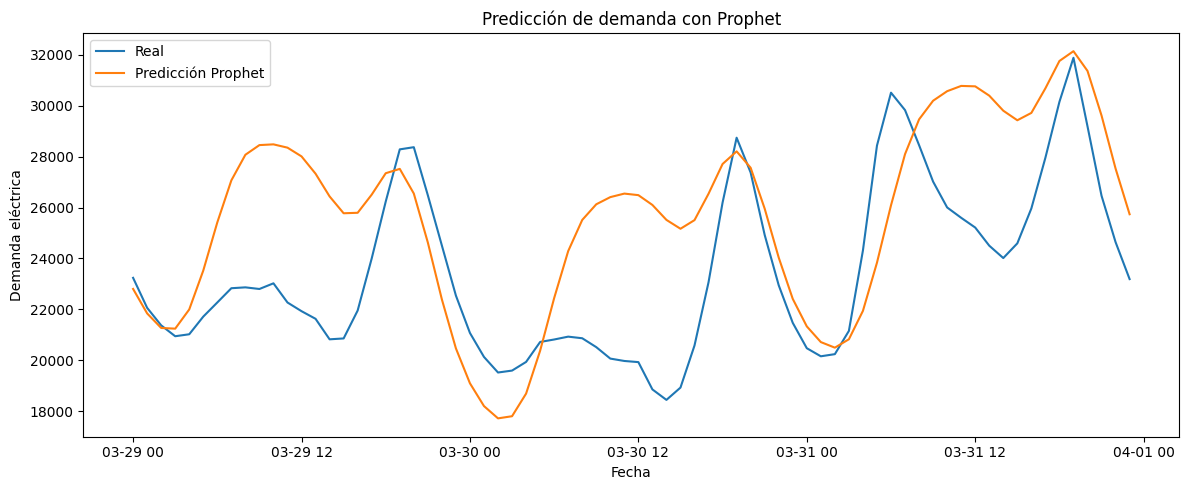

In [19]:
plt.figure(figsize=(12,5))
plt.plot(results.index, results['y'], label='Real')
plt.plot(results.index, results['yhat'], label='Predicción Prophet')
plt.title('Predicción de demanda con Prophet')
plt.xlabel('Fecha')
plt.ylabel('Demanda eléctrica')
plt.legend()
plt.tight_layout()
plt.show()